# How has collaboration in scientific research changed across arXiv fields over time? 

## 1. Has the average size of research teams changed over time across different arXiv fields?
Find whether papers are being written by larger teams than they used to be.



## Set Up File Paths

The cleaned CSV is already in `data/processed`. If it is missing, the notebook can rebuild it from the raw arXiv metadata using the cleaning script in `scripts`.


In [21]:
from pathlib import Path
import sys


def find_project_root(start=Path.cwd()):
    for folder in [start, *start.parents]:
        if (folder / "data").exists() and (folder / "scripts").exists():
            return folder
    raise FileNotFoundError("Could not find the project folder with data/ and scripts/.")


PROJECT_ROOT = find_project_root()
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "arxiv-metadata-oai-snapshot.zip"
CLEAN_FILE = PROJECT_ROOT / "data" / "processed" / "arxiv_metadata_clean.csv"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

print(f"Project folder: {PROJECT_ROOT}")
print(f"Clean data file: {CLEAN_FILE}")

Project folder: /Users/mudmi/Desktop/applied_ds_capstone
Clean data file: /Users/mudmi/Desktop/applied_ds_capstone/data/processed/arxiv_metadata_clean.csv


## Get Clean Data

This step does not download again when the clean file is already present.


In [28]:
if not CLEAN_FILE.exists():
    from clean_arxiv import run_full
    run_full(raw_file=RAW_FILE, clean_file=CLEAN_FILE)
else:
    print("Clean file already exists")

Using existing full snapshot: /Users/mudmi/Desktop/applied_ds_capstone/data/raw/arxiv-metadata-oai-snapshot.zip
Saved clean data to /Users/mudmi/Desktop/applied_ds_capstone/data/processed/arxiv_metadata_clean.csv
Saved cleaning summary to /Users/mudmi/Desktop/applied_ds_capstone/data/processed/arxiv_metadata_clean.csv.summary.json
{
  "raw_records": 3156800,
  "clean_records": 3156710,
  "dropped_duplicates": 90,
  "dropped_missing_important_values": 0,
  "important_columns": [
    "paper_id",
    "title",
    "abstract",
    "submitted_year",
    "categories",
    "authors"
  ],
  "kept_columns": [
    "paper_id",
    "title",
    "abstract",
    "submitted_year",
    "submitted_date",
    "categories",
    "primary_category",
    "authors",
    "doi",
    "journal_ref",
    "license",
    "update_date"
  ]
}


## Load Only the Needed Columns for This SubQuestion
paper ID, year, category, authors


In [30]:
import pandas as pd

cols = ["paper_id", "submitted_year", "primary_category", "authors"]
papers = pd.read_csv(CLEAN_FILE, usecols=cols, dtype={"paper_id": str})

papers.head()

,paper_id,submitted_year,primary_category,authors
0,704.0001,2007,hep-ph,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-..."
1,704.0002,2007,math.CO,Ileana Streinu and Louis Theran
2,704.0003,2007,physics.gen-ph,Hongjun Pan
3,704.0004,2007,math.CO,David Callan
4,704.0005,2007,math.CA,Wael Abu-Shammala and Alberto Torchinsky


In [31]:
print(f"Rows: {papers.shape[0]:,}")
print(f"Years: {papers['submitted_year'].min()} to {papers['submitted_year'].max()}")

Rows: 3,156,710
Years: 1986 to 2026


## Count Authors and Create a Broad Field

- split author names at `,` and `and`
- keep at least 1 author when the author text is present

- Broad Field examples: `cs.AI` `cs.LG`-> `cs` 


In [32]:
import re


def count_authors(author_text):
    text = str(author_text).strip()
    if not text:
        return 0

    text = re.sub(r"\s+and\s+", ", ", text)
    authors = [name.strip() for name in text.split(",") if name.strip()]
    return max(1, len(authors))


def broad_field(category):
    if pd.isna(category):
        return "unknown"
    return str(category).split(".")[0]


df = papers.copy()
df["submitted_year"] = pd.to_numeric(papers["submitted_year"], errors="coerce")
df = df.dropna(subset=["submitted_year", "primary_category", "authors"]).copy()
df["submitted_year"] = df["submitted_year"].astype(int)
df["author_count"] = df["authors"].apply(count_authors)
df["field"] = df["primary_category"].apply(broad_field)

df[["paper_id", "submitted_year", "primary_category", "field", "author_count"]].head()

,paper_id,submitted_year,primary_category,field,author_count
0,704.0001,2007,hep-ph,hep-ph,4
1,704.0002,2007,math.CO,math,2
2,704.0003,2007,physics.gen-ph,physics,1
3,704.0004,2007,math.CO,math,1
4,704.0005,2007,math.CA,math,2


## Overall Team Size Over Time

- mean = the average number of authors. 
- median = middle value when sorted numbers from smallest to largest.

In [33]:
overall_by_year = (
    analysis.groupby("submitted_year")["author_count"]
    .agg(papers="count", mean_authors="mean", median_authors="median")
    .reset_index()
)

overall_by_year.head()
overall_by_year.tail()

,submitted_year,papers,mean_authors,median_authors
30,2022,185987,5.435772,3.0
31,2023,209223,5.522357,3.0
32,2024,243690,5.813554,4.0
33,2025,284162,6.268442,4.0
34,2026,233830,5.852517,3.0


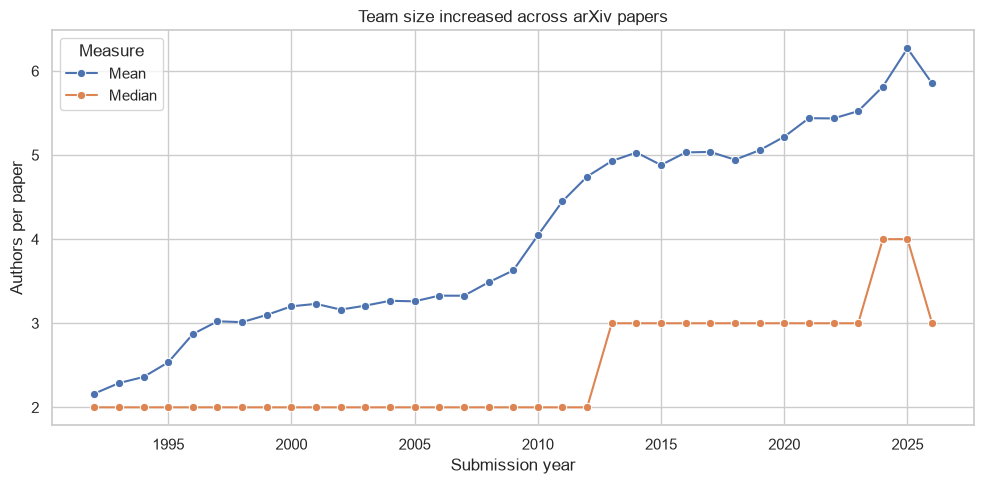

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=overall_by_year, x="submitted_year", y="mean_authors", marker="o", label="Mean", ax=ax)
sns.lineplot(data=overall_by_year, x="submitted_year", y="median_authors", marker="o", label="Median", ax=ax)
ax.set_title("Team size increased across arXiv papers")
ax.set_xlabel("Submission year")
ax.set_ylabel("Authors per paper")
ax.legend(title="Measure")
plt.tight_layout()

## Compare the Largest Fields

This table compares the early period with the recent period. 

*positive change* = teams got larger.


In [35]:
top_fields = analysis["field"].value_counts().head(8).index.tolist()

comparison_rows = []
for field in top_fields:
    field_data = analysis[analysis["field"] == field]
    early = field_data[field_data["submitted_year"].between(1992, 2000)]["author_count"]
    recent = field_data[field_data["submitted_year"].between(2017, 2026)]["author_count"]

    comparison_rows.append(
        {
            "field": field,
            "papers": len(field_data),
            "early_mean": early.mean(),
            "recent_mean": recent.mean(),
            "mean_change": recent.mean() - early.mean(),
            "early_median": early.median(),
            "recent_median": recent.median(),
        }
    )

field_comparison = pd.DataFrame(comparison_rows).sort_values("mean_change", ascending=False)
field_comparison.round(2)

,field,papers,early_mean,recent_mean,mean_change,early_median,recent_median
3,astro-ph,341976,4.34,12.90,8.57,3.0,5.0
4,physics,216375,3.00,6.21,3.21,2.0,4.0
0,cs,810930,2.43,4.65,2.22,2.0,4.0
2,cond-mat,354949,3.16,5.22,2.06,3.0,4.0
6,quant-ph,135873,2.54,4.21,1.67,2.0,3.0
5,hep-ph,144570,2.49,3.60,1.11,2.0,3.0
1,math,599145,1.70,2.24,0.54,1.0,2.0
7,hep-th,114174,2.07,2.56,0.48,2.0,2.0


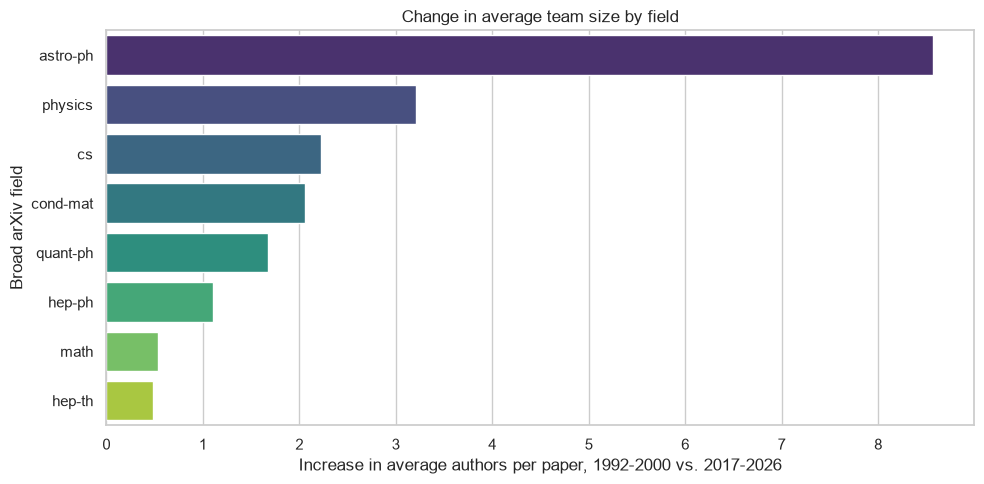

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=field_comparison,
    x="mean_change",
    y="field",
    hue="field",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Change in average team size by field")
ax.set_xlabel("Increase in average authors per paper, 1992-2000 vs. 2017-2026")
ax.set_ylabel("Broad arXiv field")
plt.tight_layout()

## Field Trends Over Time

This plot uses the median team size so the pattern is not dominated by a small number of huge collaboration papers.


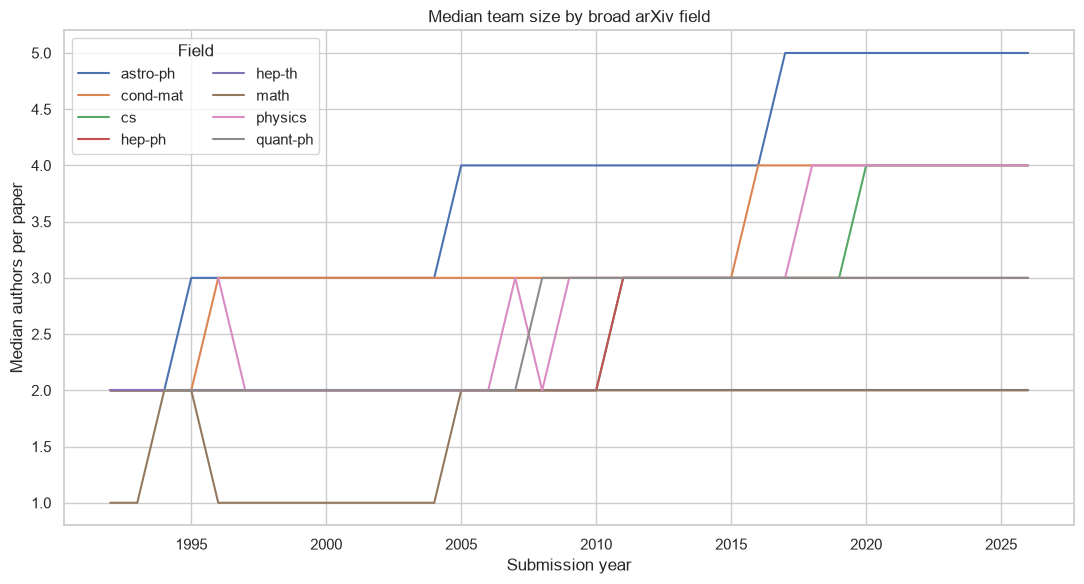

In [37]:
field_year_median = (
    analysis[analysis["field"].isin(top_fields)]
    .groupby(["field", "submitted_year"])["author_count"]
    .median()
    .reset_index(name="median_authors")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=field_year_median,
    x="submitted_year",
    y="median_authors",
    hue="field",
    ax=ax,
)
ax.set_title("Median team size by broad arXiv field")
ax.set_xlabel("Submission year")
ax.set_ylabel("Median authors per paper")
ax.legend(title="Field", ncol=2)
plt.tight_layout()

In [ ]:
start_row = overall_by_year.loc[overall_by_year["submitted_year"] == 1992].iloc[0]
end_row = overall_by_year.loc[overall_by_year["submitted_year"] == 2026].iloc[0]
biggest_change = field_comparison.iloc[0]
smallest_change = field_comparison.iloc[-1]

print("Easy summary:")
print(
    f"From 1992 to 2026, the average team size rose from "
    f"{start_row['mean_authors']:.1f} to {end_row['mean_authors']:.1f} authors per paper."
)
print(
    f"The median team size rose from {start_row['median_authors']:.0f} "
    f"to {end_row['median_authors']:.0f} authors per paper."
)
print(
    f"Among the largest fields, {biggest_change['field']} changed the most, "
    f"while {smallest_change['field']} changed the least."
)

Easy summary:
From 1992 to 2025, the average team size rose from 2.2 to 6.3 authors per paper.
The median team size rose from 2 to 4 authors per paper.
Among the largest fields, astro-ph changed the most, while hep-th changed the least.
